# Generative Adversarial Networks

![GAN](notebook_images/gan.jpg) 

A generative adversarial network (GAN) is a deep learning model that trains two neural networks -the generator and the discriminator- in competition with each other. 

The generator creates new, synthetic data from a randomly sampled latent vector (often drawn from a standard normal distribution), while the discriminator tries to distinguish between real and generated data. 

Through this adversarial process, the generator learns to produce increasingly realistic outputs until the discriminator can no longer reliably tell them apart.

This notebook introduces some common practices for creating and training GANs.

**References:**

- Generative Adversarial NetworksGenerative Adversarial Networks, Ian J. Goodfellow, Jean Pouget-Abadie, Mehdi Mirza, Bing Xu, David Warde-Farley, Sherjil Ozair, Aaron Courville, Yoshua BengioIan J. Goodfellow, Jean Pouget-Abadie, Mehdi Mirza, Bing Xu, David Warde-Farley, Sherjil Ozair, Aaron Courville, Yoshua Bengio, https://arxiv.org/abs/1406.2661
- Unsupervised Representation Learning with Deep Convolutional Generative Adversarial NetworksUnsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks, Alec Radford, Luke Metz, Soumith ChintalaAlec Radford, Luke Metz, Soumith Chintala, https://arxiv.org/abs/1511.06434

- Ahlad Kumar, Deep Learning 27 - 37: GAN and WGAN, https://www.youtube.com/watch?v=RRTuumxm3CE



In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Rectangle

import numpy as np
import time

import os
import pathlib
from PIL import Image
import skimage

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [2]:
def show_images(rows, cols, images):

    width= 2 * rows
    height= 2 * cols

    f, axes= plt.subplots(rows,cols,figsize=(height,width))
    fig=plt.figure()

    for a in range(rows*cols):

        axes.ravel()[a].imshow(np.clip(np.transpose(images[a].numpy(),(1,2,0))*0.5 + 0.5,0,1), 
                               cmap=plt.cm.gray)
        axes.ravel()[a].axis('off')
    fig.tight_layout()    
    plt.show()  

## Configuration

In [3]:
LATENT_SPACE_DIM = 16
BATCH_SIZE = 32

Normalization (scaling images to [-1, 1]) has been shown to help stabilize training and improve convergence. 

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(mean=[0.5], std=[0.5])]) 

train_set = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE,
                                          shuffle=True)

test_set = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE,
                                         shuffle=False)

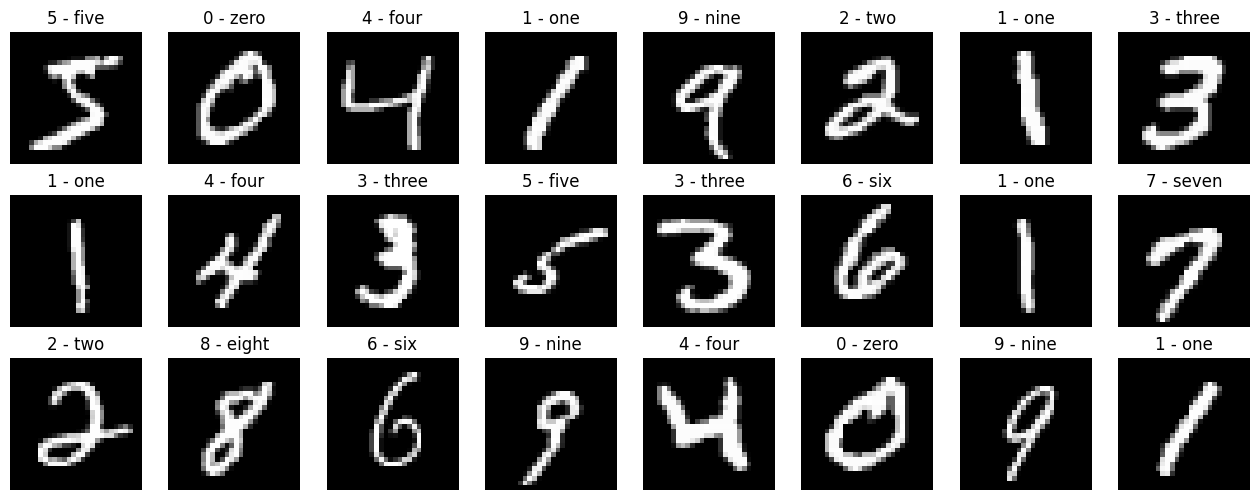

<Figure size 640x480 with 0 Axes>

In [5]:
images, targets = next(iter(train_loader))

# these are the transformed images
vcpi_util.show_transformed_images(3,8, train_set, train_set.classes) 

## Generator

The goal of the generator is to create images that resemble those in the training set.

Input: a randomly sampled latent vector

The input is reshaped as a 1x1 spatial image, where the number of channels equals the latent space dimension.

A sequence of transpose convolution layers progressively upsamples the image until it matches the target image dimension. For MNIST this would be a 28x28 image with a single channel

In [6]:
class Generator(nn.Module):

    def __init__(self, latent_dim = 16):
        super().__init__()

        self.model = nn.Sequential(
            # (batch_size, latent_dim, 1, 1)

            nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0, bias=False),
            # (batch_size, 128, 7, 7)

            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            # (batch_size, 64, 14, 14)
            
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),

            # (batch_size, 1, 28, 28)
            nn.Tanh()
        )

    def forward(self, z):
        # z shape: (batch_size, latent_dim)
        z = z.view(z.size(0), z.size(1), 1, 1)
        img = self.model(z)
        return img  # shape: (batch_size, 1, 28, 28)

In [7]:
G = Generator(LATENT_SPACE_DIM)
G.to(device)

torchinfo.summary(G, input_size = (BATCH_SIZE, LATENT_SPACE_DIM,1,1),
                                     col_names=["kernel_size", "input_size", "output_size", "num_params", "mult_adds"])

Layer (type:depth-idx)                   Kernel Shape              Input Shape               Output Shape              Param #                   Mult-Adds
Generator                                --                        [32, 16, 1, 1]            [32, 1, 28, 28]           --                        --
├─Sequential: 1-1                        --                        [32, 16, 1, 1]            [32, 1, 28, 28]           --                        --
│    └─ConvTranspose2d: 2-1              [7, 7]                    [32, 16, 1, 1]            [32, 128, 7, 7]           100,352                   157,351,936
│    └─BatchNorm2d: 2-2                  --                        [32, 128, 7, 7]           [32, 128, 7, 7]           256                       8,192
│    └─ReLU: 2-3                         --                        [32, 128, 7, 7]           [32, 128, 7, 7]           --                        --
│    └─ConvTranspose2d: 2-4              [4, 4]                    [32, 128, 7, 7]           

Feeding a random noise vector to an untrained Generator should provide an output that looks like random noise.

torch.Size([32, 1, 28, 28])


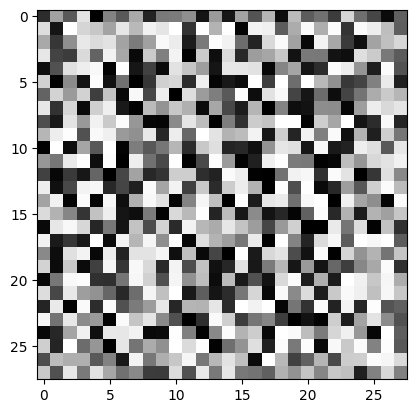

In [8]:
noise = torch.randn(BATCH_SIZE, LATENT_SPACE_DIM, 1, 1, device=device)

out = G(noise)
print(out.shape)

plt.imshow(np.transpose(out[0].detach().cpu().numpy() * 0.5 + 0.5, (1,2,0)), cmap='gray')

## Discriminator

The goal of the Discriminator is to discriminate (:-)) between real images and fake images produced by the generator.

Input: an image

The Discriminator is typically a standard CNN, with a single output value between 0 and 1, representing the probability that the input image is real.



In [9]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Input: (batch_size, 1, 28, 28)
            nn.Conv2d(1, 64, 4, 2, 1, bias=True),   # No batchnorm in first layer
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [10]:
D = Discriminator()
D.to(device)

torchinfo.summary(D, input_size = (BATCH_SIZE, 1,28,28),
                                     col_names=["kernel_size", "input_size", "output_size", "num_params", "mult_adds"])

Layer (type:depth-idx)                   Kernel Shape              Input Shape               Output Shape              Param #                   Mult-Adds
Discriminator                            --                        [32, 1, 28, 28]           [32, 1]                   --                        --
├─Sequential: 1-1                        --                        [32, 1, 28, 28]           [32, 1]                   --                        --
│    └─Conv2d: 2-1                       [4, 4]                    [32, 1, 28, 28]           [32, 64, 14, 14]          1,088                     6,823,936
│    └─LeakyReLU: 2-2                    --                        [32, 64, 14, 14]          [32, 64, 14, 14]          --                        --
│    └─Conv2d: 2-3                       [4, 4]                    [32, 64, 14, 14]          [32, 128, 7, 7]           131,072                   205,520,896
│    └─BatchNorm2d: 2-4                  --                        [32, 128, 7, 7]       

Feeding an image to an untrained discriminator should result in an output around 0.5

In [11]:
res = D(out)
print(len(res),res[0])

32 tensor([0.5868], device='cuda:0', grad_fn=<SelectBackward0>)


In [12]:
loss_fn = torch.nn.BCELoss()

real_label = 1.0
fake_label = 0.0

optim_D = torch.optim.Adam(D.parameters(), lr=0.0001)
optim_G = torch.optim.Adam(G.parameters(), lr=0.0001)

## Training

Each epoch is a two stage process:

- Train the discriminator
- Train the generator

### Discriminator Training: 

The **Discriminator** is trained on:

- A batch of real images from the dataset, with labels set to 1 (real)
- A batch of fake images generated by the Generator, with labels set to 0 (fake).

The **Discriminator** aims to maximize:

$$ log(D(x))+log(1−D(G(z)))$$

where 

- $x$ is a real image
- $G(z)$ is a fake image produced by the Generator from random noise $z$

Code wise, this corresponds to using the BCE Loss with real labels (1) for real images, and fake labels (0) for fake images

### Generator Training: 

The **generator** is trained on a batch of latent vectors $z$, with the  goal of making the discriminator classify the produced images as real (labels set to 1). 

The **generator** aims to maximize:

$$ log (D(G(z))) $$

In code, we use BCE Loss with real labels (1) for the fake images, encouraging the Generator to fool the Discriminator.



Starting Training
[0][1874/1875]	Loss_D: 0.5593	Loss_G: 1.7246


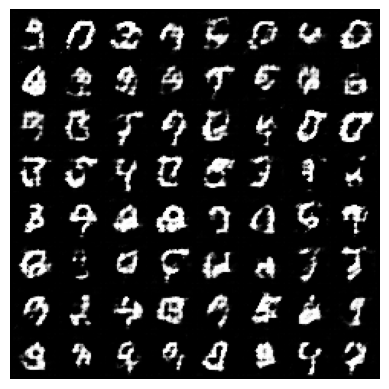

[1][1874/1875]	Loss_D: 0.3947	Loss_G: 1.9290
[2][1874/1875]	Loss_D: 0.3785	Loss_G: 1.4928
[3][1874/1875]	Loss_D: 0.5846	Loss_G: 1.9906
[4][1874/1875]	Loss_D: 0.7904	Loss_G: 1.9054
[5][1874/1875]	Loss_D: 0.5463	Loss_G: 1.8204
[6][1874/1875]	Loss_D: 0.6601	Loss_G: 1.8048
[7][1874/1875]	Loss_D: 0.8044	Loss_G: 1.1982
[8][1874/1875]	Loss_D: 0.5117	Loss_G: 1.4660
[9][1874/1875]	Loss_D: 0.6657	Loss_G: 1.8008
[10][1874/1875]	Loss_D: 0.9751	Loss_G: 1.3653


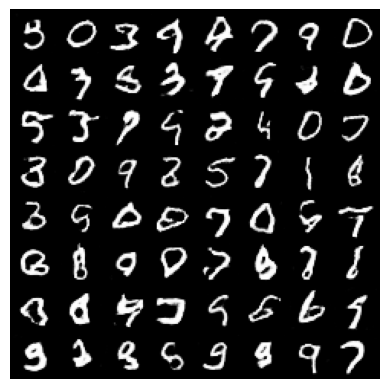

[11][1874/1875]	Loss_D: 1.0186	Loss_G: 1.0369
[12][1874/1875]	Loss_D: 0.3420	Loss_G: 2.4860
[13][1874/1875]	Loss_D: 0.6525	Loss_G: 2.1188
[14][1874/1875]	Loss_D: 0.8093	Loss_G: 2.0934
[15][1874/1875]	Loss_D: 0.9739	Loss_G: 3.5500
[16][1874/1875]	Loss_D: 0.8087	Loss_G: 1.4654
[17][1874/1875]	Loss_D: 0.4572	Loss_G: 1.4302
[18][1874/1875]	Loss_D: 0.5126	Loss_G: 2.4564
[19][1874/1875]	Loss_D: 0.3067	Loss_G: 2.9769
[20][1874/1875]	Loss_D: 0.5606	Loss_G: 1.9389


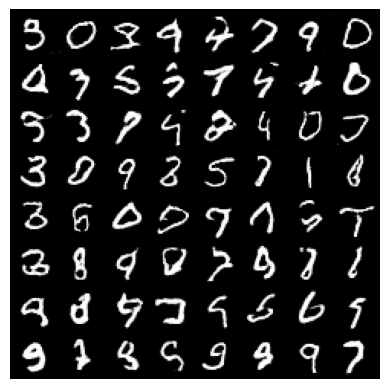

[21][1874/1875]	Loss_D: 0.6127	Loss_G: 2.4132
[22][1874/1875]	Loss_D: 0.5638	Loss_G: 1.5355
[23][1874/1875]	Loss_D: 0.6012	Loss_G: 2.0924
[24][1874/1875]	Loss_D: 0.5393	Loss_G: 1.7308
[25][1874/1875]	Loss_D: 0.4695	Loss_G: 3.4811
[26][1874/1875]	Loss_D: 0.6260	Loss_G: 1.8550
[27][1874/1875]	Loss_D: 0.7648	Loss_G: 2.2856
[28][1874/1875]	Loss_D: 0.7949	Loss_G: 1.2575
[29][1874/1875]	Loss_D: 0.9407	Loss_G: 1.0812


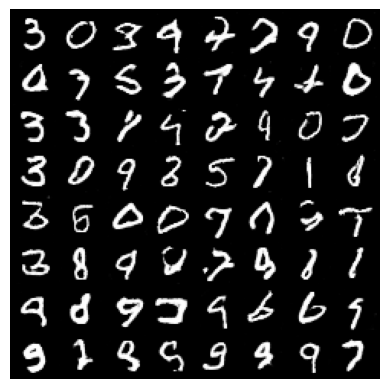

In [13]:
print("Starting Training")

EPOCHS = 30

D.train()
G.train()
D.to(device)
G.to(device)

latent_vis = torch.randn(64, LATENT_SPACE_DIM, 1, 1, device=device)

for epoch in range(EPOCHS):
    for i, (digits, _) in enumerate(train_loader):

        #####################
        # Train Discriminator
        #####################

        optim_D.zero_grad()
        digits = digits.to(device)
        
        # Real images
        out_D_real = D(digits).view(-1)     
        labels = torch.full((len(digits),), real_label, dtype=torch.float, device=device)
        err_D_real = loss_fn(out_D_real, labels)
        err_D_real.backward()

        # Fake images
        latent = torch.randn(len(digits), LATENT_SPACE_DIM, 1, 1, device=device)
        fakes = G(latent)
        out_D_fakes = D(fakes.detach()).view(-1)
        labels.fill_(fake_label)
        err_D_fake = loss_fn(out_D_fakes, labels)
        err_D_fake.backward()

        err_D = err_D_real + err_D_fake
        optim_D.step()

        #################
        # Train Generator
        #################

        optim_G.zero_grad()
        labels.fill_(real_label)  # Generator wants discriminator to think fakes are real
        out = D(fakes).view(-1)
        err_G = loss_fn(out, labels)
        err_G.backward()
        optim_G.step()

    # stats
    print('[%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f'
            % (epoch, i, len(train_loader),
                err_D.item(), err_G.item()))

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        with torch.no_grad():
            fake = G(latent_vis).detach().cpu()
        grid = torchvision.utils.make_grid(fake, padding=2, normalize=True)
        plt.imshow(np.transpose(grid, (1, 2, 0)))
        plt.axis('off')
        plt.show()

    torch.save({
        'epoch': epoch,
        'generator': G.state_dict(),
        'optim_G': optim_G.state_dict(),
        'discriminator': D.state_dict(),
        'optim_D': optim_D.state_dict()
        },
        f'models_gan_mnist/gan_mnist_{LATENT_SPACE_DIM}_{epoch}.pt')

# Evaluating GANs

When using a classifiers the accuracy is a clear indication of a model's performance.

When evaluating GANs the errors obtained are not a useful metric. What we really want is to know if the faces generated by the Generator model are close to the real faces.



## Fréchet Inception Distance (FID)

To compare the difference between samples taken from two distributions the Fréchet Distance can be computed as follows:

- In 1D the difference could be computed as

$d = (\mu_1 - \mu_2)^2 + (\sigma_1^2 + \sigma_2^2 - 2\sigma_1\sigma_2)$

where $\mu_1$, $\mu_2$ are the means and $\sigma_1$, $\sigma_2$ are the standard deviations of the two samples.

- Generalizing to n-D, this assumes that the samples come from Multivariate Normal Distribution, computing the Fréchet Distance becomes:

$d = ||\mu_1 – \mu_2||^2 + Tr(\Sigma_1 + \Sigma_2 – 2*\sqrt(\Sigma_1*\Sigma_2))$

where $\Sigma_1$, $\Sigma_2$ are the covariance matrices of the two distributions.

Ref: Dowson and Landau, [The Frechet Distance between Multivariate Normal Distributions](https://core.ac.uk/reader/82269844)

Directly applying the above to images would benefit similarity, which is not the goal of a GAN. Furthermore, images would be compared based on their pixels, so considering a face dataset, some of the face main features, e.g. the position of the mouth, can be totally wrong and still the computed distance could be low, The goal of a GAN would be to generate new faces, that share the features of real faces, like having a nose in the proper place, two eyes, a mouth, etc ... So we need to compare features and not actual pixels.

Pre-trained models on ImageNet have learned to extract image features that are then used by the classifier head. Hence, these models can be used to compute features of an image, by looking at the output of the convolutional blocks. 

By computing the Frechet Distance between two sets of image features, we can get a grasp of their difference.

Therefore, instead of working with the actual images, we work with the features extracted by an InceptionV3 model trained on ImageNet, hence the name **Fréchet Inception Distance**.

FID was introduce in the following paper:

Ref: Martin Heusel, Hubert Ramsauer, Thomas Unterthiner, Bernhard Nessler, and Sepp Hochreiter (2017),  [GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium](https://arxiv.org/abs/1706.08500)




"FID has been widely adopted because of its consistency with human inspection and sensitivity to small changes in the real distribution (e.g. slight blurring or small artifacts in synthesized images)"

Ref: Ali Borji, [Pros and cons of GAN evaluation measures: New developments](https://www.sciencedirect.com/science/article/abs/pii/S1077314221001685#preview-section-references)

However, FID requires a very large number of samples to be unbiased, meaning it becomes computationally expensive. Furthermore, the normality assumption can lead to incorrect results. 

Furthermore, some authors show that FID does not agree with human perception of image quality for instance:

Ref: Jayasumana, Ramalingam, Veit, Glasner, [Rethinking FID: Towards a Better Evaluation Metric for Image Generation](https://arxiv.org/html/2401.09603v2)




## Spatial Fréchet Inception Distance (SFID)

SFID works in a similar way to FID, the main difference being that, instead of collecting features from the final pooled layer, it uses features maps from an intermediate layer from the Inception network.

These intermediate layers are feature maps, i.e. 3D tensors (Channels, width, height), as opposed to the 1D vector as in FID. Having spatial information allows to capture local patterns, texture information, and other information that the global pooling (used in FID) would average.

SFID seems to be a community-driven extension to FID wih no clear paper claiming its authorship. Nevertheless, it is described and used in several papers such as: [Facial Image Feature Analysis and its Specialization for Fréchet Distance and Neighborhoods](https://arxiv.org/html/2406.18430v1) (2024), [StyleGAN-XL: Scaling StyleGAN to Large Diverse Datasets](https://arxiv.org/pdf/2202.00273) (2022)

SFID is further extended in CFID, which collects features from multiple layers.

Ref: Eric J. Nunn, Pejman Khadivi, Shadrokh Samavi (2021) [Compound Fréchet Inception Distance (CFID)](https://arxiv.org/pdf/2106.08575)






## CLIP-based Maximum Mean Discrepancy (CMMD)

CMMD uses CLIP embeddings and MMD with a Gaussian kernel to measure the distance between real and generated image distributions.

Algorithm:

- Embed both real and generated images using CLIP
    - $X = \{x_1, x_2, x_m\}$: Embeddings of real images
    - $Y = \{y_1, y_2, y_n\}$: Embeddings of generated images

- Compute MMD

$$
\mathrm{MMD}^2(X, Y) = \frac{1}{m(m-1)} \sum_{i=1}^m \sum_{\substack{j=1 \\ j \neq i}}^m k(x_i, x_j)
- \frac{2}{mn} \sum_{i=1}^m \sum_{j=1}^n k(x_i, y_j)
+ \frac{1}{n(n-1)} \sum_{i=1}^n \sum_{\substack{j=1 \\ j \neq i}}^n k(y_i, y_j)
$$

with

$$
k(x, y) = \exp\left(-\frac{\|x - y\|^2}{2\sigma^2}\right)
$$

where
- $\sigma$ is the kernel size (larger kernels will provide lower scores)

A lower CMMD score, $\mathrm{MMD}^2(X, Y)$, indicates closer distributions.

Ref: Jayasumana, Ramalingam, Veit, Glasner, [Rethinking FID: Towards a Better Evaluation Metric for Image Generation](https://arxiv.org/html/2401.09603v2)


According to the authors, CMMD compares favourably to FID because:

- There is **no assumption** that the data follows a **Normal distribution**
- CLIP embeddings provide **richer features**
- MMD is an unbiased metric, implying it requires  **fewer images**, compared to FID,  to provide a stable result.
